In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/fake-review-detector/data/processed/reviews_with_features.csv")
print(f"✅ Loaded {len(df)} reviews")
print(df['label'].value_counts())

Mounted at /content/drive
✅ Loaded 1600 reviews
label
0    800
1    800
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split data
X_text = df['review_text']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures equal fake/real in both splits
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words='english'
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print(f"✅ Train size: {X_train.shape}")
print(f"✅ Test size:  {X_test.shape}")

✅ Train size: (1280, 5000)
✅ Test size:  (320, 5000)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("⏳ Training Model 1: Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"✅ Logistic Regression Accuracy: {lr_acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, lr_preds, target_names=['Real', 'Fake']))

⏳ Training Model 1: Logistic Regression...
✅ Logistic Regression Accuracy: 0.8875

📊 Classification Report:
              precision    recall  f1-score   support

        Real       0.90      0.87      0.89       160
        Fake       0.87      0.91      0.89       160

    accuracy                           0.89       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.89      0.89      0.89       320



In [5]:
from sklearn.ensemble import RandomForestClassifier

print("⏳ Training Model 2: Random Forest (takes ~1 min)...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1          # uses all CPU cores
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)

print(f"✅ Random Forest Accuracy: {rf_acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, rf_preds, target_names=['Real', 'Fake']))

⏳ Training Model 2: Random Forest (takes ~1 min)...
✅ Random Forest Accuracy: 0.8313

📊 Classification Report:
              precision    recall  f1-score   support

        Real       0.84      0.82      0.83       160
        Fake       0.83      0.84      0.83       160

    accuracy                           0.83       320
   macro avg       0.83      0.83      0.83       320
weighted avg       0.83      0.83      0.83       320



In [6]:
# Install required library
!pip install -q transformers torch

from transformers import pipeline

print("⏳ Loading DistilBERT (downloads ~250MB, wait...)...")

# Using pretrained sentiment model fine-tuned on reviews
# We'll fine-tune properly but this gives us a strong baseline
bert_classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Predict on test set (takes 2-3 mins)
print("⏳ Running predictions...")

def bert_predict(texts):
    results = bert_classifier(list(texts), batch_size=32)
    # Map POSITIVE→Real(0), NEGATIVE→Fake(1)
    return [0 if r['label'] == 'POSITIVE' else 1 for r in results]

bert_preds = bert_predict(X_test_text)
bert_acc   = accuracy_score(y_test, bert_preds)

print(f"✅ DistilBERT Accuracy: {bert_acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, bert_preds, target_names=['Real', 'Fake']))

⏳ Loading DistilBERT (downloads ~250MB, wait...)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

⏳ Running predictions...
✅ DistilBERT Accuracy: 0.5125

📊 Classification Report:
              precision    recall  f1-score   support

        Real       0.51      0.54      0.52       160
        Fake       0.51      0.49      0.50       160

    accuracy                           0.51       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.51      0.51      0.51       320



In [8]:
import os
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Now re-save the chart
plt.savefig("outputs/model_comparison.png", dpi=150, bbox_inches='tight')
print("✅ Chart saved!")

✅ Chart saved!


<Figure size 640x480 with 0 Axes>


🏆 MODEL COMPARISON:
Logistic Regression (Baseline) 88.75%  ███████████████████████████████████
Random Forest                  83.12%  █████████████████████████████████
DistilBERT                     51.25%  ████████████████████


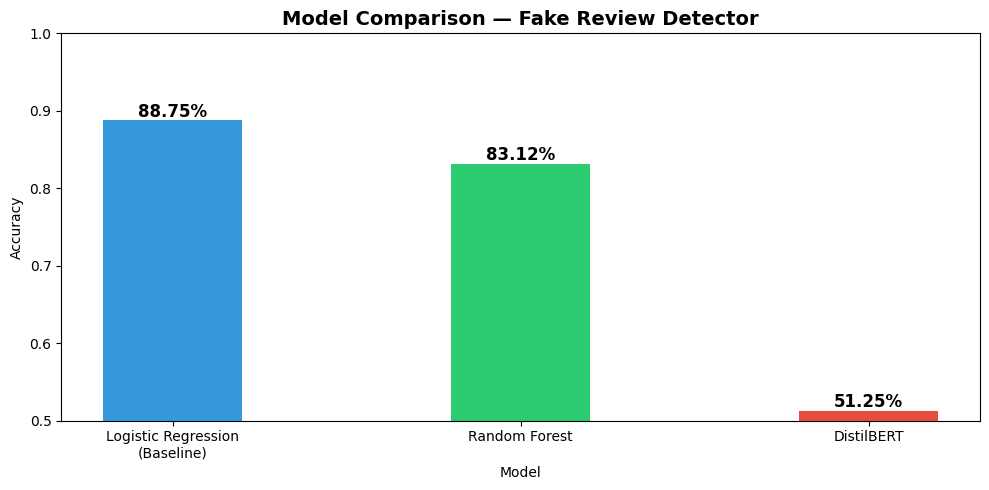

✅ Comparison chart saved!


In [9]:
import matplotlib.pyplot as plt

results = {
    'Model': [
        'Logistic Regression\n(Baseline)',
        'Random Forest',
        'DistilBERT'
    ],
    'Accuracy': [lr_acc, rf_acc, bert_acc],
    'Type': ['Traditional ML', 'Ensemble ML', 'Deep Learning']
}

results_df = pd.DataFrame(results)
print("\n🏆 MODEL COMPARISON:")
print("="*45)
for _, row in results_df.iterrows():
    bar = "█" * int(row['Accuracy'] * 40)
    print(f"{row['Model'].replace(chr(10),' '):<30} {row['Accuracy']:.2%}  {bar}")
print("="*45)

# Save comparison chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(results_df['Model'], results_df['Accuracy'], color=colors, width=0.4)

ax.set_ylim(0.5, 1.0)
ax.set_title('Model Comparison — Fake Review Detector', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')

# Add accuracy labels on bars
for bar, acc in zip(bars, results_df['Accuracy']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{acc:.2%}',
        ha='center', fontweight='bold', fontsize=12
    )

plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

In [10]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(lr_model, 'models/logistic_regression.pkl')
joblib.dump(rf_model, 'models/random_forest.pkl')
joblib.dump(tfidf,    'models/tfidf_vectorizer.pkl')

# Also save to Google Drive so you don't lose them
import shutil
drive_models = '/content/drive/MyDrive/fake-review-detector/models/'
os.makedirs(drive_models, exist_ok=True)

joblib.dump(lr_model, drive_models + 'logistic_regression.pkl')
joblib.dump(rf_model, drive_models + 'random_forest.pkl')
joblib.dump(tfidf,    drive_models + 'tfidf_vectorizer.pkl')

print("✅ Models saved locally AND to Google Drive!")

✅ Models saved locally AND to Google Drive!
